### Create db where all mask except crack related are set to background (removed) and all crack classes are combined into one#

In [1]:
import os
import shutil
import numpy as np
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from skmultilearn.model_selection import iterative_train_test_split
import random

DEFECT_NAMES = {
    0: 'bg',
    1: 'cracks',
    2: 'cracks_alligator',
    3: 'cracks_severe',
    4: 'edge_breaks',
    5: 'fretting',
    6: 'pothole',
    7: 'manhole',
    8: 'patched',
    9: 'bad_joint',
    10: 'joint',
    11: 'large_repair',
    12: 'loose_stones',
    13: 'pole_shadow',
    14: 'sill',
    15: 'tyre_mark',
    16: 'edge_grass'
}

REMAPPED_NAMES = {
    0: 'bg', 1: 'cracks', 2: 'cracks_alligator', 3: 'cracks_severe',
    4: 'edge_breaks', 5: 'fretting', 6: 'pothole',
    7: 'manhole', 8: 'pole_shadow' 
}

# --- CONFIGURATION ---
BASE_DIR = '/app/data/2026-01-19-defect_dataset'
SOURCE_IMG_DIR = f'{BASE_DIR}/images'
SOURCE_LBL_DIR = f'{BASE_DIR}/labels_full'

# Output directory changes based on your choice
OUT_BASE_MERGED = f'{BASE_DIR}/labels_cracks_merged'
OUT_BASE_MULTICLASS = f'{BASE_DIR}/labels_basic_defects_3'

In [2]:
def analyze_dataset_distribution(source_dir, include_bg=True, class_mapping=None):
    """
    Scans a directory of segmentation masks and calculates the pixel area 
    and instance frequency for every class.
    """
    if class_mapping is None:
        class_mapping = {}

    image_to_pixel_counts = defaultdict(dict)
    class_total_pixels = defaultdict(int)
    class_instance_counts = defaultdict(int)
    
    try:
        label_files = [f for f in os.listdir(source_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    except FileNotFoundError:
        print(f" Error: Could not find label directory at {source_dir}")
        return None, None, None
    
    total_images = len(label_files)
    bg_text = "INCLUDING" if include_bg else "EXCLUDING"
    print(f"🚀 Scanning {total_images} labels in '{os.path.basename(source_dir)}' ({bg_text} background)...")
    
    for f in label_files:
        mask = np.array(Image.open(os.path.join(source_dir, f)).convert('L'))
        unique_classes, counts = np.unique(mask, return_counts=True)
        
        for cls_id, count in zip(unique_classes, counts):
            if not include_bg and cls_id == 0:
                continue
            image_to_pixel_counts[f][cls_id] = count
            class_total_pixels[cls_id] += count
            class_instance_counts[cls_id] += 1
            
    print("\n" + "="*100)
    print(f"{'Class ID':<10} | {'Class Name':<18} | {'Total Pixel Area':<20} | {'Image Instances':<18} | {'Appearance %'}")
    print("-" * 100)
    
    for cls_id in sorted(class_total_pixels.keys()):
        pixels = class_total_pixels[cls_id]
        instances = class_instance_counts[cls_id]
        appearance_pct = (instances / total_images) * 100
        cls_name = class_mapping.get(cls_id, f"Unknown ({cls_id})")
        print(f"{cls_id:<10} | {cls_name:<18} | {pixels:<20,} | {instances:<18} | {appearance_pct:>10.2f}%")
    print("="*100 + "\n")

    return image_to_pixel_counts, class_total_pixels, class_instance_counts


In [3]:
def plot_defect_density(img_pixels):
    print("📊 Generating Defect Density Chart...")
    
    # 1. Count defects per image (ignoring background 0), capping at 4 for the chart
    counts = [min(sum(1 for c, p in mask.items() if c != 0 and p > 0), 4) for mask in img_pixels.values()]
    
    # 2. Count frequencies and map to readable labels
    labels = {0: "0 (Healthy)", 1: "1 Defect", 2: "2 Defects", 3: "3 Defects", 4: "4+ Defects"}
    df = pd.Series(counts).map(labels).value_counts().reindex(labels.values()).fillna(0)

    # 3. Plot it simply
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=df.index, y=df.values, hue=df.index, palette="viridis", legend=False)
    ax.bar_label(ax.containers[0], fmt='%g', padding=3) # Instantly adds the exact numbers on top of the bars!
    
    plt.title("Multi-Label Complexity: Defect Types per Image", fontweight='bold')
    plt.ylabel("Number of Images")
    sns.despine()
    plt.show()

In [4]:
def plot_dataset_distribution(image_to_pixel_counts, class_total_pixels, class_mapping=None):
    """
    Takes the computed distribution data and generates the Class Co-occurrence Matrix
    and Relative Size Distribution Boxplot.
    """
    if class_mapping is None:
        class_mapping = {}

    # Dynamically find the actual defect classes present (ignoring 0/background)
    target_classes = sorted([cls for cls in class_total_pixels.keys() if cls != 0])
    num_classes = len(target_classes)
    class_labels = [class_mapping.get(c, f"Class {c}") for c in target_classes]

    if num_classes == 0:
        print("⚠️ No defect classes found to plot (only background detected).")
        return

    # --- PLOT A: Co-occurrence Matrix ---
    print("📊 Generating Class Co-occurrence Matrix...")
    co_matrix = np.zeros((num_classes, num_classes), dtype=int)
    id_to_idx = {cls_id: i for i, cls_id in enumerate(target_classes)}

    for pixels_dict in image_to_pixel_counts.values():
        present_defects = [cls for cls, count in pixels_dict.items() if cls != 0 and count > 0]
        for i in range(len(present_defects)):
            for j in range(len(present_defects)):
                if present_defects[i] in id_to_idx and present_defects[j] in id_to_idx:
                    idx1, idx2 = id_to_idx[present_defects[i]], id_to_idx[present_defects[j]]
                    co_matrix[idx1, idx2] += 1

    plt.figure(figsize=(10, 8))
    sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title("Defect Co-occurrence Matrix (Number of Shared Images)", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --- PLOT B: Relative Size Distribution ---
    print("📊 Generating Relative Size Distribution...")
    area_distributions = {cls_id: [] for cls_id in target_classes}

    for pixels_dict in image_to_pixel_counts.values():
        total_image_pixels = sum(pixels_dict.values())
        if total_image_pixels == 0: continue 

        for cls_id, count in pixels_dict.items():
            if cls_id != 0 and count > 0 and cls_id in area_distributions:
                pct_area = (count / total_image_pixels) * 100
                area_distributions[cls_id].append(pct_area)

    plot_data = []
    for cls_id, areas in area_distributions.items():
        name = class_mapping.get(cls_id, f"Class {cls_id}")
        for area in areas:
            plot_data.append({'Defect': name, 'Area %': area})

    if plot_data:
        df_plot = pd.DataFrame(plot_data)
        plt.figure(figsize=(12, 6))
        
        # Using the updated seaborn syntax to prevent the deprecation warning
        sns.boxplot(data=df_plot, x='Defect', y='Area %', hue='Defect', palette="Set2", legend=False)
        
        plt.title("Relative Defect Size Distribution (% of Image Area)", fontsize=14)
        plt.ylabel("Percentage of Image Area (%)")
        plt.xlabel("Defect Class")
        plt.xticks(rotation=45, ha='right')
        plt.yscale('log') 
        plt.tight_layout()
        plt.show()

In [5]:
def plot_spatial_heatmaps(source_dir, class_mapping, target_ids=[1, 2, 6]):
    """Generates heatmaps by padding masks to a common canvas size to handle mixed resolutions."""
    print("🎨 Generating Spatial Heatmaps...")
    files = [f for f in os.listdir(source_dir) if f.endswith('.png')][:500] 
    
    canvas_h, canvas_w = 720, 1280 
    
    # If target_ids is a dictionary (like REMAPPED_NAMES), use its keys
    ids_to_plot = target_ids.keys() if isinstance(target_ids, dict) else target_ids

    for cls_id in ids_to_plot:
        if cls_id == 0: continue # Skip background
        
        # Create a blank canvas for the current class
        combined_heatmap = np.zeros((canvas_h, canvas_w), dtype=np.float32)
        found_any = False
        
        for f in files:
            mask = np.array(Image.open(os.path.join(source_dir, f)))
            h, w = mask.shape
            temp_canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)
            temp_canvas[:h, :w] = (mask == cls_id).astype(np.float32)
            combined_heatmap += temp_canvas
            if np.any(mask == cls_id):
                found_any = True
        
        if found_any:
            plt.figure(figsize=(10, 5))
            sns.heatmap(combined_heatmap, cmap='magma', cbar=True)
            plt.title(f"Spatial Distribution: {class_mapping.get(cls_id, cls_id)}")
            plt.axis('off')
            plt.show()
        else:
            print(f"No instances of {class_mapping.get(cls_id, cls_id)} found in sample.")


🚀 Scanning 7286 labels in 'labels_full' (INCLUDING background)...

Class ID   | Class Name         | Total Pixel Area     | Image Instances    | Appearance %
----------------------------------------------------------------------------------------------------
0          | bg                 | 5,752,144,948        | 7286               |     100.00%
1          | cracks             | 51,913,060           | 5403               |      74.16%
2          | cracks_alligator   | 115,280,971          | 1754               |      24.07%
3          | cracks_severe      | 11,652,921           | 1408               |      19.32%
4          | edge_breaks        | 2,450,468            | 336                |       4.61%
5          | fretting           | 93,126,458           | 1649               |      22.63%
6          | pothole            | 5,018,917            | 921                |      12.64%
7          | manhole            | 2,375,090            | 494                |       6.78%
8          | patched 

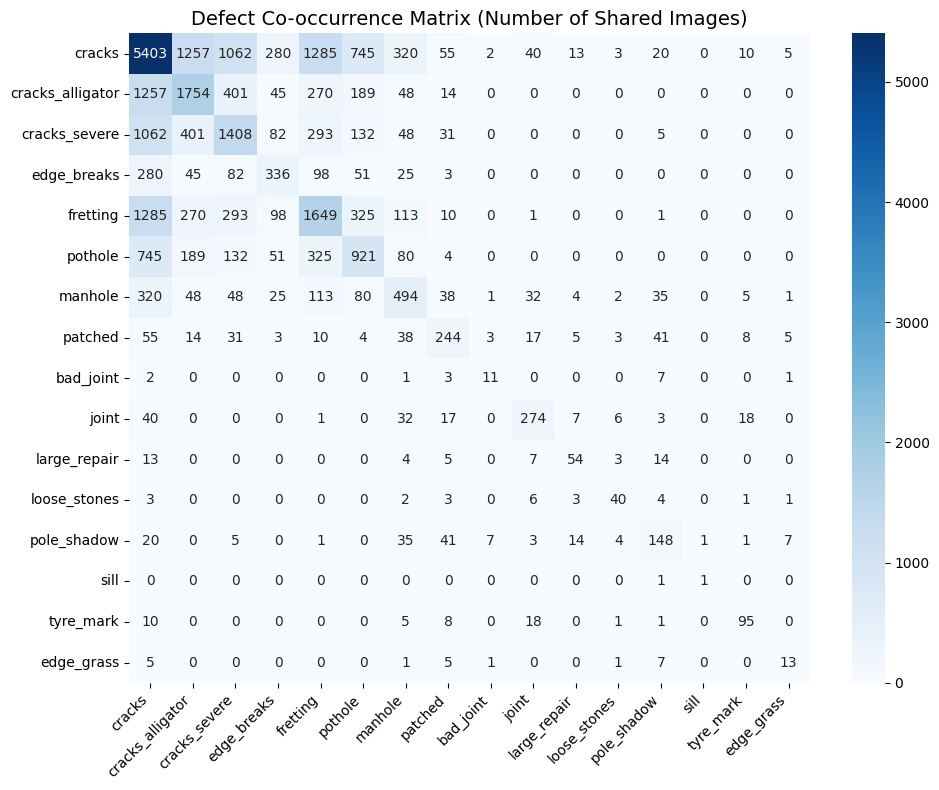

📊 Generating Relative Size Distribution...


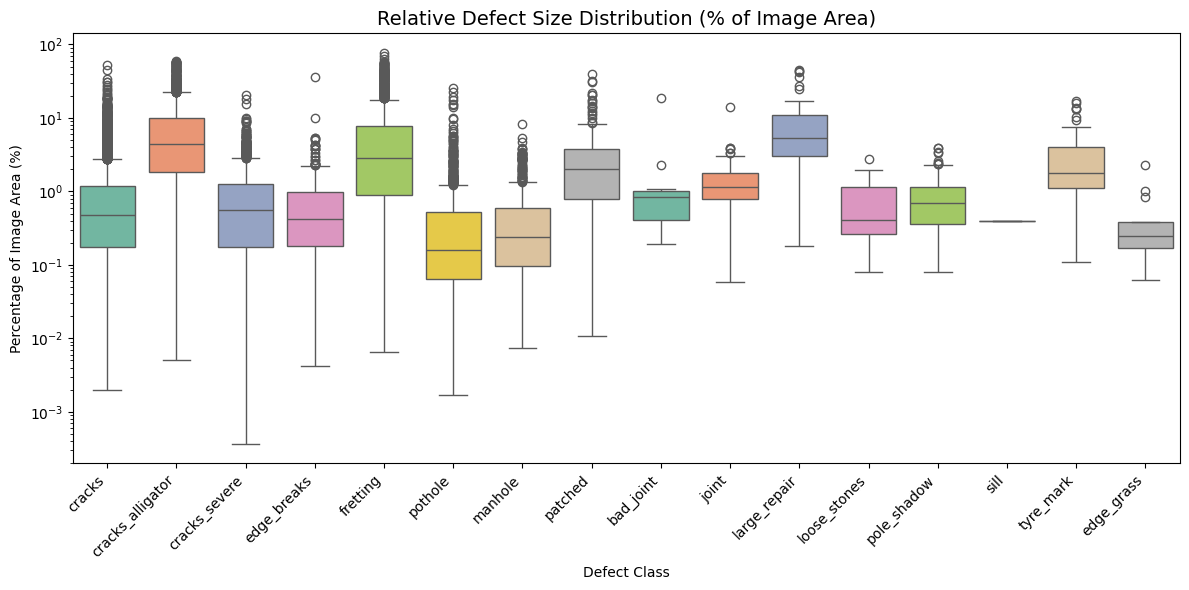

📊 Generating Defect Density Chart...


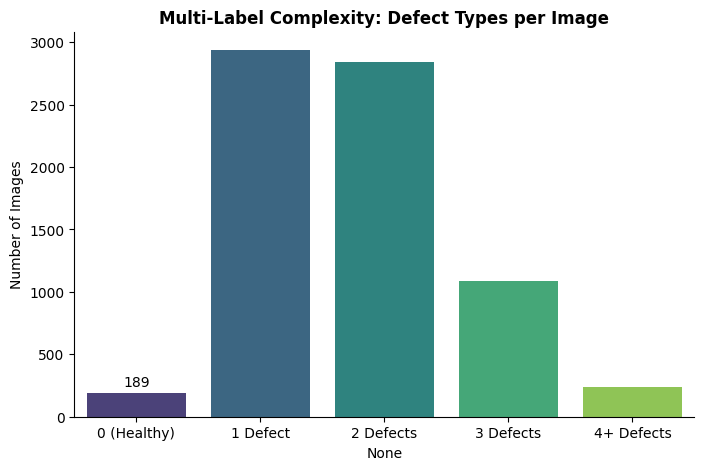

In [6]:
# Distribution analysis with all the classes
img_pixels, cls_pixels, cls_instances = analyze_dataset_distribution(
    SOURCE_LBL_DIR, 
    include_bg=True, 
    class_mapping=DEFECT_NAMES
)

plot_dataset_distribution(img_pixels, cls_pixels, class_mapping=DEFECT_NAMES)

plot_defect_density(img_pixels)

In [7]:
# Data Integrity Check: Match RGB Images to Segmentation Masks

print("🚨 Locating Orphaned Images...")

# 1. Identify the exact orphans
imgs = {os.path.splitext(f)[0] for f in os.listdir(SOURCE_IMG_DIR) if f.endswith(('.jpg', '.png'))}
original_masks = {os.path.splitext(f)[0] for f in os.listdir(SOURCE_LBL_DIR) if f.endswith('.png')}
orphans = list(imgs - original_masks)

print(f"Found {len(orphans)} orphans: {orphans}\n")

# 2. Display them on the screen
if orphans:
    fig, axes = plt.subplots(1, len(orphans), figsize=(20, 5))
    if len(orphans) == 1: axes = [axes] # Safety catch for 1 image
    
    orphan_paths = []
    
    for ax, orphan in zip(axes, orphans):
        # Find the exact file with its original extension
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(SOURCE_IMG_DIR, orphan + ext)
            if os.path.exists(img_path):
                orphan_paths.append(img_path)
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(orphan + ext)
                ax.axis('off')
                break
                
    plt.tight_layout()
    plt.show()

    print("\n🗑️ Deleting orphans...")
    for path in orphan_paths:
        os.remove(path)
        print(f"Deleted: {path}")
    print("Done! You can now re-run the Data Integrity Check.")

🚨 Locating Orphaned Images...
Found 0 orphans: []



In [8]:
# Data Integrity Check: Match RGB Images to Segmentation Masks
imgs = {os.path.splitext(f)[0] for f in os.listdir(SOURCE_IMG_DIR) if f.endswith(('.jpg', '.png'))}
original_masks = {os.path.splitext(f)[0] for f in os.listdir(SOURCE_LBL_DIR) if f.endswith('.png')}

assert imgs == original_masks , f"🚨 Mismatch! Orphans: {len(imgs - original_masks)} images without masks, {len(original_masks - imgs)} masks without images."
print(f"✅ Data Integrity Passed: Exactly {len(imgs)} matching image-mask pairs.")

✅ Data Integrity Passed: Exactly 7286 matching image-mask pairs.


In [9]:
"""Scans the image directory and returns a count of all unique resolutions."""
print(f"🔍 Analyzing image resolutions in: {SOURCE_IMG_DIR}")

resolutions = {}
image_files = [f for f in os.listdir(SOURCE_IMG_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]

for f in image_files:
    path = os.path.join(SOURCE_IMG_DIR, f)
    with Image.open(path) as img:
        # size returns (width, height)
        res = img.size
        resolutions[res] = resolutions.get(res, 0) + 1
        
print("\n" + "="*40)
print(f"{'Resolution (W x H)':<25} | {'Count'}")
print("-" * 40)
for res, count in sorted(resolutions.items(), key=lambda item: item[1], reverse=True):
    print(f"{str(res):<25} | {count}")
print("="*40)

🔍 Analyzing image resolutions in: /app/data/2026-01-19-defect_dataset/images

Resolution (W x H)        | Count
----------------------------------------
(1280, 640)               | 6454
(1280, 720)               | 832


In [10]:
# Verify image and mask sizes match for a random sample

mismatches = []
for f in os.listdir(OUT_BASE_MULTICLASS):
    img_name = os.path.splitext(f)[0]
    img_p = next((os.path.join(SOURCE_IMG_DIR, f"{img_name}{e}") for e in ['.jpg', '.png', '.jpeg'] 
                  if os.path.exists(os.path.join(SOURCE_IMG_DIR, f"{img_name}{e}"))), None)
    
    if img_p:
        with Image.open(img_p) as i, Image.open(os.path.join(OUT_BASE_MULTICLASS, f)) as m:
            if i.size != m.size: mismatches.append(f"{f}: {i.size} vs {m.size}")

assert not mismatches, f"❌ Mismatches found: {mismatches[:5]}"
print(f"✅ 100% Sync: All {len(os.listdir(OUT_BASE_MULTICLASS))} pairs match perfectly.")

✅ 100% Sync: All 7286 pairs match perfectly.


Text(0.5, 1.0, 'Dataset Illumination Distribution')

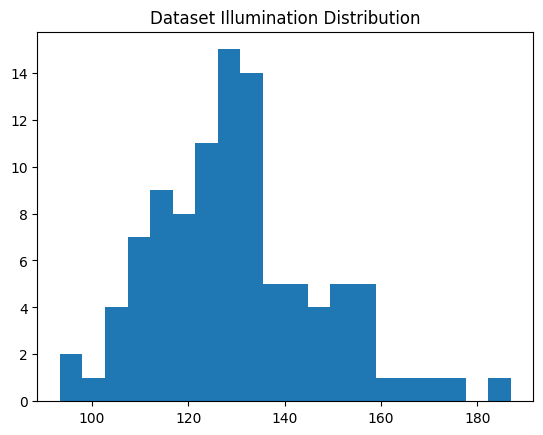

In [11]:

# Analysis of Brightness on images 
import cv2
brightness_vals = [cv2.cvtColor(cv2.imread(os.path.join(SOURCE_IMG_DIR, f)), cv2.COLOR_BGR2HSV)[:,:,2].mean() 
                   for f in random.sample(os.listdir(SOURCE_IMG_DIR), 100)]
plt.hist(brightness_vals, bins=20); plt.title("Dataset Illumination Distribution")

In [12]:
# Remapping labels to be 1-8 and save new db

TARGET_CLASS_IDS = [1, 2, 3, 4, 5, 6, 7, 13]

multi_mapping = np.zeros(256, dtype=np.uint8)
for new_id, old_id in enumerate(TARGET_CLASS_IDS, start=1):
    multi_mapping[old_id] = new_id

if os.path.exists(OUT_BASE_MULTICLASS):
    print(f"🧹 Clearing existing directory to prevent ghost labels: {OUT_BASE_MULTICLASS}")
    shutil.rmtree(OUT_BASE_MULTICLASS)
    
os.makedirs(OUT_BASE_MULTICLASS, exist_ok=True)

mapping = multi_mapping

label_files = [f for f in os.listdir(SOURCE_LBL_DIR) if f.endswith('.png')]
processed_count = 0
empty_count = 0

print(f"Processing {len(label_files)} files...")

for lbl_file in label_files:
    src_lbl_path = os.path.join(SOURCE_LBL_DIR, lbl_file)
    mask = np.array(Image.open(src_lbl_path).convert('L'))

    new_mask = mapping[mask]
    
    # Skip if no target pixels exist in the final mask
    if not np.any(new_mask > 0):
        empty_count += 1

    # Save Label
    Image.fromarray(new_mask).save(os.path.join(OUT_BASE_MULTICLASS, lbl_file))
    processed_count += 1

print(f"✅ Saved: {processed_count} images | ❌ Empty: {empty_count}")
print(f"📂 Location: {OUT_BASE_MULTICLASS}")

🧹 Clearing existing directory to prevent ghost labels: /app/data/2026-01-19-defect_dataset/labels_basic_defects_3
Processing 7286 files...
✅ Saved: 7286 images | ❌ Empty: 609
📂 Location: /app/data/2026-01-19-defect_dataset/labels_basic_defects_3


In [13]:
# Verify the relabel was done correctly 
label_files = os.listdir(OUT_BASE_MULTICLASS)
global_unique_ids = set()
errors = []
TARGET_CLASS_IDS = [0, 1, 2, 3, 4, 5, 6, 7, 8]

label_files = [f for f in os.listdir(OUT_BASE_MULTICLASS) if f.endswith(('.png', '.jpg', '.jpeg'))]
total_images = len(label_files)

for f in label_files:
    path = os.path.join(OUT_BASE_MULTICLASS, f)
    # Load the newly created mask
    mask = np.array(Image.open(path).convert('L'))
    unique = np.unique(mask)
    
    # Update global list of IDs found
    for u in unique:
        global_unique_ids.add(u)
    
    if not np.all(np.isin(unique, TARGET_CLASS_IDS)):
        errors.append(f)

print("-" * 30)
print(f"Found unique class IDs across all files: {sorted(list(global_unique_ids))}")

if len(errors) == 0 and global_unique_ids.issubset(TARGET_CLASS_IDS):
    print(f"✅ SUCCESS: Dataset contains {sorted(list(global_unique_ids))} across exactly {total_images} files.")
else:
    print(f"❌ FAILURE: Found unexpected classes or files with errors: {errors}")


------------------------------
Found unique class IDs across all files: [0, 1, 2, 3, 4, 5, 6, 7, 8]
✅ SUCCESS: Dataset contains [0, 1, 2, 3, 4, 5, 6, 7, 8] across exactly 7286 files.


In [14]:
# Data Integrity Check: Match RGB Images to Segmentation Masks
imgs = {os.path.splitext(f)[0] for f in os.listdir(SOURCE_IMG_DIR) if f.endswith(('.jpg', '.png'))}
new_masks = {os.path.splitext(f)[0] for f in os.listdir(OUT_BASE_MULTICLASS) if f.endswith('.png')}

assert imgs == new_masks , f"🚨 Mismatch! Orphans: {len(imgs - new_masks)} images without masks, {len(new_masks - imgs)} masks without images."
print(f"✅ Data Integrity Passed: Exactly {len(imgs)} matching image-mask pairs.")

✅ Data Integrity Passed: Exactly 7286 matching image-mask pairs.


Gathering class distribution data...
🚀 Scanning 7286 labels in 'labels_basic_defects_3' (INCLUDING background)...

Class ID   | Class Name         | Total Pixel Area     | Image Instances    | Appearance %
----------------------------------------------------------------------------------------------------
0          | bg                 | 5,770,881,764        | 7286               |     100.00%
1          | cracks             | 51,913,060           | 5403               |      74.16%
2          | cracks_alligator   | 115,280,971          | 1754               |      24.07%
3          | cracks_severe      | 11,652,921           | 1408               |      19.32%
4          | edge_breaks        | 2,450,468            | 336                |       4.61%
5          | fretting           | 93,126,458           | 1649               |      22.63%
6          | pothole            | 5,018,917            | 921                |      12.64%
7          | manhole            | 2,375,090            | 494   

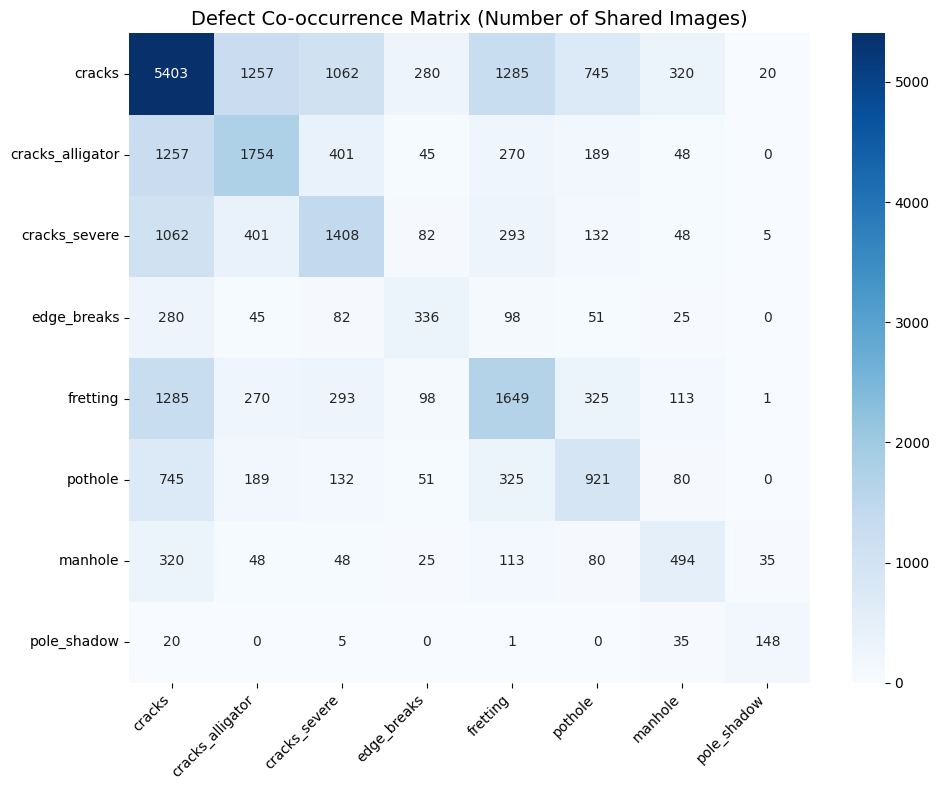

📊 Generating Relative Size Distribution...


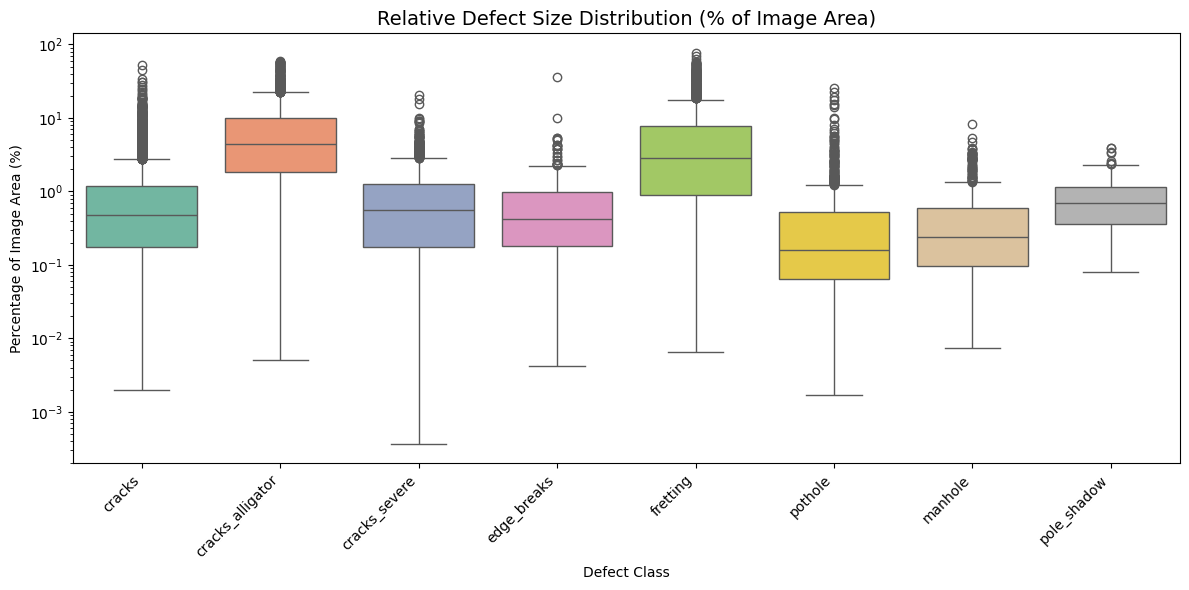

📊 Generating Defect Density Chart...


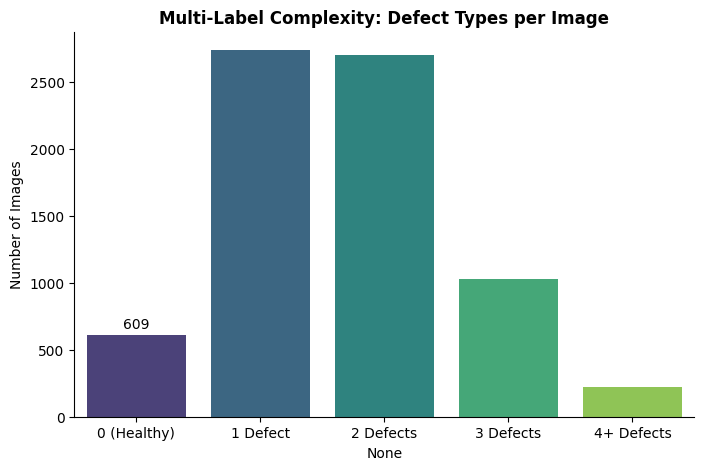

🎨 Generating Spatial Heatmaps...


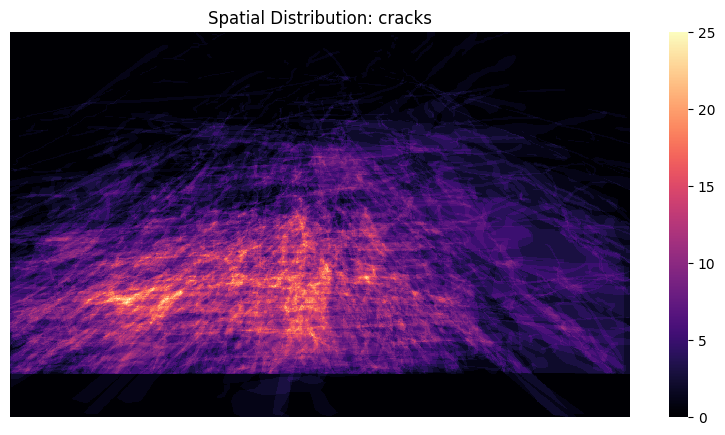

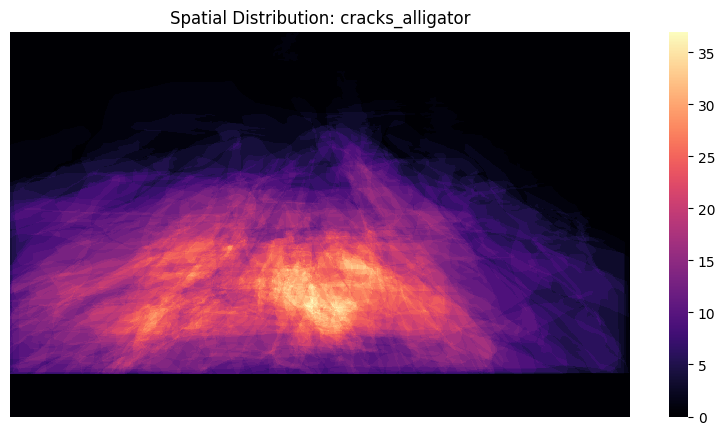

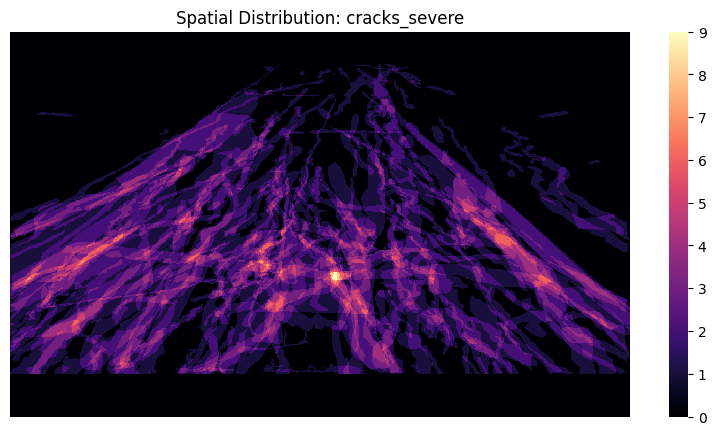

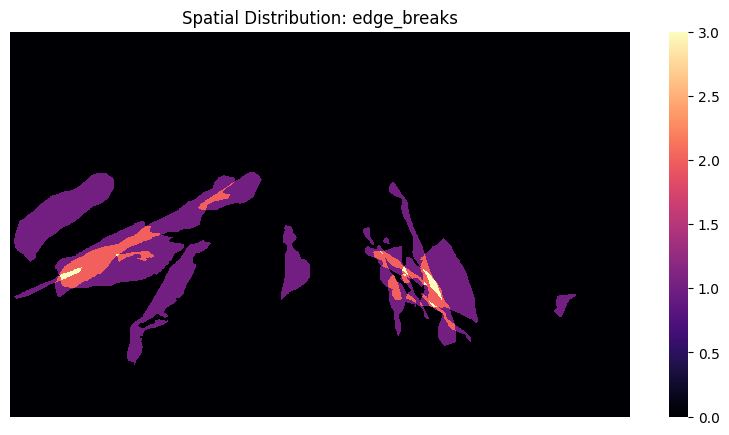

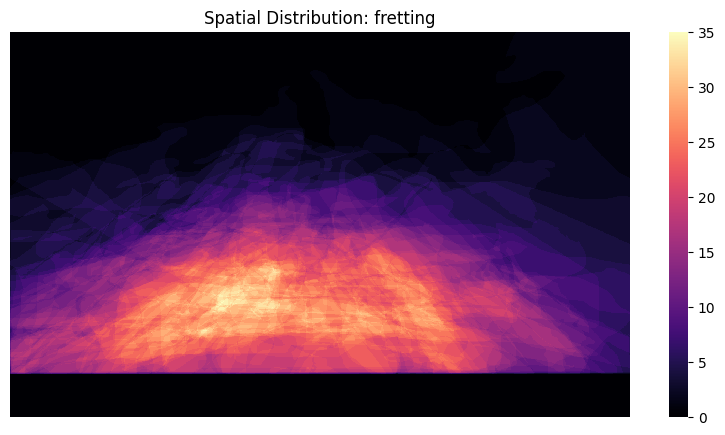

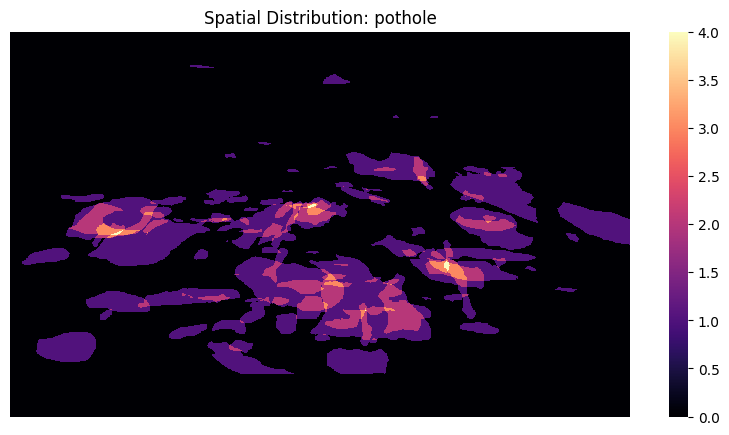

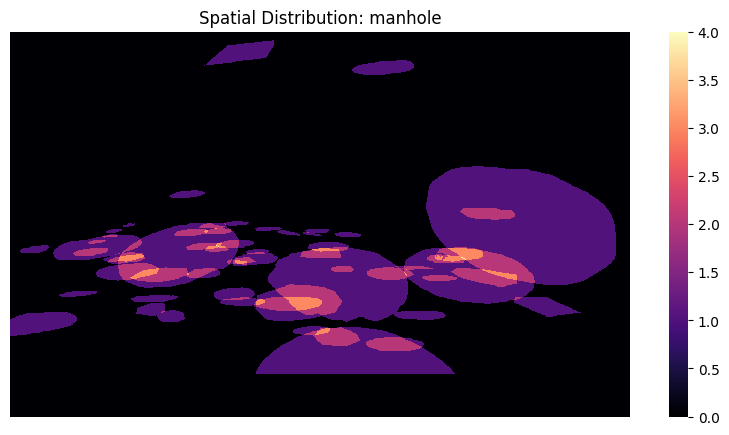

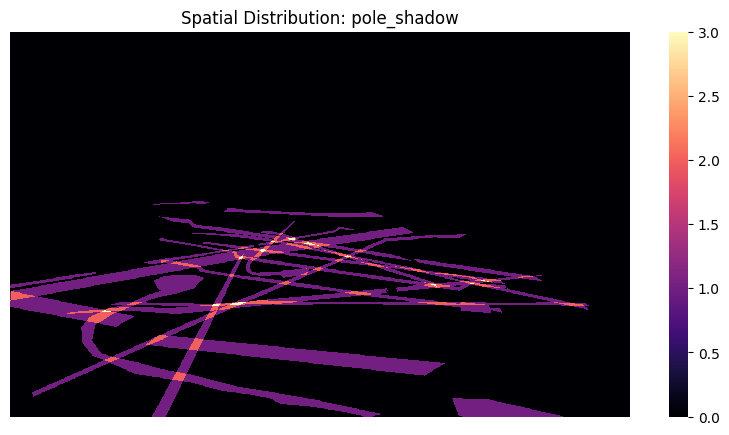

In [15]:
print("Gathering class distribution data...")

img_pixels, cls_pixels, cls_instances = analyze_dataset_distribution(
    OUT_BASE_MULTICLASS, 
    include_bg=True, 
    class_mapping=REMAPPED_NAMES
)

plot_dataset_distribution(img_pixels, cls_pixels, class_mapping=REMAPPED_NAMES)

plot_defect_density(img_pixels)

plot_spatial_heatmaps(OUT_BASE_MULTICLASS, REMAPPED_NAMES, target_ids=REMAPPED_NAMES)

In [16]:
# Create stratifies split based on distribution

# 2. Build the binary presence matrix (y) and filename array (X)
X_list = list(img_pixels.keys())
max_cls = max([cls for img in img_pixels.values() for cls in img.keys()])

y_list = []
for f in X_list:
    # Create an array of zeros for the classes
    presence = np.zeros(max_cls + 1, dtype=int)
    has_defect = False
    
    for cls_id in img_pixels[f].keys():
        if cls_id != 0:  # Ignore background for stratification
            presence[cls_id] = 1
            has_defect = True
    if not has_defect:
        presence[0] = 1
            
    y_list.append(presence)

# skmultilearn requires X to be a 2D array
X = np.array(X_list).reshape(-1, 1) 
y = np.array(y_list)

# 3. Perform the 80/20 Split (Separates Train from Temp)
print("\n⚖️ Performing Iterative Stratification...")
X_train, y_train, X_temp, y_temp = iterative_train_test_split(X, y, test_size=0.2)

# 4. Perform the 50/50 Split on Temp (Separates Val and Test)
X_val, y_val, X_test, y_test = iterative_train_test_split(X_temp, y_temp, test_size=0.5)

# Flatten back to 1D lists of filenames
train_files = X_train.flatten()
val_files = X_val.flatten()
test_files = X_test.flatten()

print(f"✅ Split Complete:")
print(f"  Train: {len(train_files)} images ({len(train_files)/len(X)*100:.1f}%)")
print(f"  Val:   {len(val_files)} images ({len(val_files)/len(X)*100:.1f}%)")
print(f"  Test:  {len(test_files)} images ({len(test_files)/len(X)*100:.1f}%)")


⚖️ Performing Iterative Stratification...
✅ Split Complete:
  Train: 5829 images (80.0%)
  Val:   733 images (10.1%)
  Test:  724 images (9.9%)


In [17]:
# Analyze distribution of each subset to ensure quality 

print("\n" + "="*90)
print(f"{'Class Name':<18} | {'Train Inst (%)':<20} | {'Val Inst (%)':<18} | {'Test Inst (%)':<18}")
print("-" * 90)

def count_classes(files):
    counts = defaultdict(int)
    empty_roads = 0
    for f in files:
        has_defect = False
        for cls_id in img_pixels[f]:
            if cls_id != 0: 
                counts[cls_id] += 1
                has_defect = True
        if not has_defect:
            empty_roads += 1
    counts[0] = empty_roads # Track empty roads for the printout
    return counts
    
train_inst = count_classes(train_files)
val_inst = count_classes(val_files)
test_inst = count_classes(test_files)

all_classes = sorted(set(train_inst) | set(val_inst) | set(test_inst))

for cls_id in all_classes:
    t, v, ts = train_inst[cls_id], val_inst[cls_id], test_inst[cls_id]
    total = t + v + ts
    
    # Label 0 as Healthy Road, and properly map the rest
    cls_name = "Healthy Road (BG)" if cls_id == 0 else REMAPPED_NAMES.get(cls_id, f"Class {cls_id}")
    
    print(f"{cls_name:<18} | "
          f"{t:>5} ({t/total*100:>5.1f}%) | "
          f"{v:>5} ({v/total*100:>5.1f}%) | "
          f"{ts:>5} ({ts/total*100:>5.1f}%)")
print("="*90)


Class Name         | Train Inst (%)       | Val Inst (%)       | Test Inst (%)     
------------------------------------------------------------------------------------------
Healthy Road (BG)  |   487 ( 80.0%) |    61 ( 10.0%) |    61 ( 10.0%)
cracks             |  4322 ( 80.0%) |   540 ( 10.0%) |   541 ( 10.0%)
cracks_alligator   |  1403 ( 80.0%) |   175 ( 10.0%) |   176 ( 10.0%)
cracks_severe      |  1126 ( 80.0%) |   141 ( 10.0%) |   141 ( 10.0%)
edge_breaks        |   269 ( 80.1%) |    36 ( 10.7%) |    31 (  9.2%)
fretting           |  1319 ( 80.0%) |   165 ( 10.0%) |   165 ( 10.0%)
pothole            |   737 ( 80.0%) |    87 (  9.4%) |    97 ( 10.5%)
manhole            |   395 ( 80.0%) |    49 (  9.9%) |    50 ( 10.1%)
pole_shadow        |   118 ( 79.7%) |    15 ( 10.1%) |    15 ( 10.1%)


In [18]:
# Save splits 

def write_split(files, split_name):
    names = [os.path.splitext(f)[0] for f in files]
    with open(os.path.join(f'{BASE_DIR}/splits', f'{split_name}.txt'), 'w') as f:
        f.write('\n'.join(names))

write_split(train_files, 'train')
write_split(val_files, 'val')
write_split(test_files, 'test')

print(f"\n💾 MMSegmentation splits successfully saved to {BASE_DIR}/splits")


💾 MMSegmentation splits successfully saved to /app/data/2026-01-19-defect_dataset/splits


In [21]:
def compute_multiclass_stats_and_weights(train_files_list, img_dir, lbl_dir, num_classes=9):
    print("⚙️ Calculando Media/Std RGB y Pesos de Clase (9 Clases)...")
    
    pixel_num = 0
    channel_sum = np.zeros(3)
    channel_sum_squared = np.zeros(3)
    
    # Array para contar los píxeles de cada clase (0 a 8)
    class_pixel_counts = np.zeros(num_classes, dtype=np.int64)
    
    for filename in train_files_list:
        base_name = os.path.splitext(filename)[0]
        
        # Paths
        img_path = next((os.path.join(img_dir, f"{base_name}{ext}") for ext in ['.jpg', '.png', '.jpeg'] 
                         if os.path.exists(os.path.join(img_dir, f"{base_name}{ext}"))), None)
        lbl_path = os.path.join(lbl_dir, f"{base_name}.png")
        
        if not img_path or not os.path.exists(lbl_path):
            continue
            
        # 1. Estadísticas RGB
        img = np.array(Image.open(img_path).convert('RGB')) / 255.0
        pixel_num += (img.shape[0] * img.shape[1])
        channel_sum += np.sum(img, axis=(0, 1))
        channel_sum_squared += np.sum(np.square(img), axis=(0, 1))
        
        # 2. Conteo de píxeles por clase en la nueva máscara
        mask = np.array(Image.open(lbl_path).convert('L'))
        unique, counts = np.unique(mask, return_counts=True)
        for u, c in zip(unique, counts):
            if u < num_classes:
                class_pixel_counts[u] += c

    # Finalizar estadísticas RGB
    rgb_mean = channel_sum / pixel_num
    rgb_std = np.sqrt((channel_sum_squared / pixel_num) - np.square(rgb_mean))
    
    # Calcular pesos de clase usando Inverse Class Frequency
    total_valid_pixels = np.sum(class_pixel_counts)
    class_weights = []
    for count in class_pixel_counts:
        # Evitar división por cero
        weight = total_valid_pixels / (num_classes * count) if count > 0 else 0.0
        class_weights.append(round(weight, 4))
    
    print("\n--- Valores para MMSegmentation config.py ---")
    print(f"img_norm_cfg = dict(")
    print(f"    mean={[round(x * 255, 3) for x in rgb_mean]},")
    print(f"    std={[round(x * 255, 3) for x in rgb_std]},")
    print(f"    to_rgb=True)")
    print(f"\n# Pesos de las 9 clases (Fondo + 8 Defectos) para usar en CrossEntropyLoss o FocalLoss:")
    print(f"class_weights = {class_weights}")

# Llama a la función apuntando al directorio de las máscaras ya procesadas de 9 clases
compute_multiclass_stats_and_weights(train_files, SOURCE_IMG_DIR, OUT_BASE_MULTICLASS, num_classes=9)

⚙️ Calculando Media/Std RGB y Pesos de Clase (9 Clases)...

--- Valores para MMSegmentation config.py ---
img_norm_cfg = dict(
    mean=[117.306, 121.072, 112.199],
    std=[58.415, 57.541, 65.498],
    to_rgb=True)

# Pesos de las 9 clases (Fondo + 8 Defectos) para usar en CrossEntropyLoss o FocalLoss:
class_weights = [0.1166, 12.8472, 5.9544, 56.2898, 316.9984, 7.0135, 137.9534, 280.7874, 592.7112]
